In [1]:
import ast
import pandas as pd 
from datasets import load_dataset
import matplotlib.pyplot as plt 


dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date']= pd.to_datetime(df['job_posted_date'])
df['job_skills']= df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x) 

c:\Users\TOLU\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/datasets/lukebarousse/data_jobs/resolve/ed776e5a0a8c40ea9d5efbd800772ae52e140f3e/data_jobs.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since lukebarousse/data_jobs couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\TOLU\.cache\huggingface\datasets\lukebarousse___data_jobs\default\0.0.0\ed776e5a0a8c40ea9d5efbd800772ae52e140f3e (last modified on Thu Mar  5 19:06:55 2026).


In [2]:
df_DA_US=df[(df['job_country']== 'United States') & (df['job_title_short']== 'Data Analyst')].copy()

df_DA_US.dropna(subset=['salary_year_avg'],inplace= True)

In [3]:
type(df)

pandas.core.frame.DataFrame

In [4]:
df_DA_US=df_DA_US.explode('job_skills')

In [5]:
df_DA_US[['salary_year_avg','job_skills']]

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel
...,...,...
784882,87500.0,sql
784882,87500.0,vba
784882,87500.0,tableau
784882,87500.0,excel


In [6]:
df_DA_US_group = df_DA_US.groupby('job_skills', )['salary_year_avg'].agg(count='count', median= 'median')

In [7]:
df_DA_US_top_pay = df_DA_US_group.sort_values('median',ascending=False).head(10)
df_DA_US_top_skills = df_DA_US_group.sort_values('count', ascending=False).head(10).sort_values('median',ascending= False)



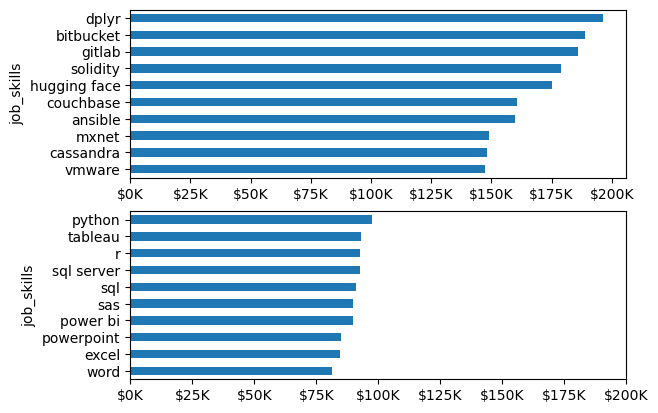

In [ ]:
fig, ax = plt.subplots(2, 1)

df_DA_US_top_pay[::-1].plot(kind='barh', y= 'median',ax=ax[0],legend =False)
df_DA_US_top_skills[::-1].plot(kind='barh',y='median', ax=ax[1],legend =False)
ax[1].set_xlim(0, 200000)

for a in ax:
    a.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
#ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.show()
